In [78]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
import seaborn as sns
import scipy.stats as stats
import sklearn
import statsmodels.api as sm
from sklearn import preprocessing
from sklearn.preprocessing import scale
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [79]:
prices = pd.read_csv('laptop_price.csv', encoding='cp1252')  # or
prices.dtypes
#prices
prices.dtypes
prices

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [80]:
na_counts = prices.isna().sum()
na_counts

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [81]:
prices['Memory_Names'] = prices.loc[:, 'Memory']
prices = prices[['laptop_ID','Company','Product','TypeName','Inches','ScreenResolution','Cpu','Ram','Memory','Memory_Names','Gpu','OpSys','Weight','Price_euros']]

In [82]:
all_brands = set()
all_brands.update(prices['Company'].unique())

brand_values = {}
value = 0
for brand in sorted(all_brands):
        brand_values[brand] = value
        value += 1

prices['Company'] = prices['Company'].apply(lambda x: brand_values[x])

In [83]:
all_product = set()
all_product.update(prices['Product'].unique())

product_values = {}
value = 0
for product in sorted(all_product):
        product_values[product] = value
        value += 1

prices['Product'] = prices['Product'].apply(lambda x: product_values[x])

In [84]:
my_set = set()
my_set.update(prices['TypeName'].unique())

set_values = {}
value = 0
for item in sorted(my_set):
        set_values[item] = value
        value += 1

prices['TypeName'] = prices['TypeName'].apply(lambda x: set_values[x])

In [85]:
my_set = set()
my_set.update(prices['ScreenResolution'].unique())

set_values = {}
value = 0
for item in sorted(my_set):
        set_values[item] = value
        value += 1

prices['ScreenResolution'] = prices['ScreenResolution'].apply(lambda x: set_values[x])

In [86]:
my_set = set()
my_set.update(prices['Cpu'].unique())

set_values = {}
value = 0
for item in sorted(my_set):
        set_values[item] = value
        value += 1

prices['Cpu'] = prices['Cpu'].apply(lambda x: set_values[x])

In [87]:
prices['Ram'] = prices['Ram'].str.strip('GB')
prices['Ram'] = prices['Ram'].astype(int)

In [88]:
prices['Memory'] = prices['Memory'].str.extract(r'(\d+)')
prices['Memory'] = prices['Memory'].astype(int)

In [89]:
prices['Weight'] = prices['Weight'].str.strip('kg')
prices['Weight'] = prices['Weight'].astype(float)

In [90]:
my_set = set()
my_set.update(prices['Gpu'].unique())

set_values = {}
value = 0
for item in sorted(my_set):
        set_values[item] = value
        value += 1

prices['Gpu'] = prices['Gpu'].apply(lambda x: set_values[x])

In [91]:
my_set = set()
my_set.update(prices['Memory_Names'].unique())

set_values = {}
value = 0
for item in sorted(my_set):
        set_values[item] = value
        value += 1

prices['Memory_Names'] = prices['Memory_Names'].apply(lambda x: set_values[x])

In [92]:
my_set = set()
my_set.update(prices['OpSys'].unique())

set_values = {}
value = 0
for item in sorted(my_set):
        set_values[item] = value
        value += 1

prices['OpSys'] = prices['OpSys'].apply(lambda x: set_values[x])

In [93]:
prices.dtypes

laptop_ID             int64
Company               int64
Product               int64
TypeName              int64
Inches              float64
ScreenResolution      int64
Cpu                   int64
Ram                   int32
Memory                int32
Memory_Names          int64
Gpu                   int64
OpSys                 int64
Weight              float64
Price_euros         float64
dtype: object

In [94]:
prices

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Memory_Names,Gpu,OpSys,Weight,Price_euros
0,1,1,300,4,13.3,23,65,8,128,4,58,8,1.37,1339.69
1,2,1,301,4,13.3,1,63,8,128,2,51,8,1.34,898.94
2,3,7,50,3,15.6,8,74,8,256,16,53,4,1.86,575.00
3,4,1,300,4,15.4,25,85,16,512,29,9,8,1.83,2537.45
4,5,1,300,4,13.3,23,67,8,256,16,59,8,1.37,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,10,580,0,14.0,13,89,4,128,4,47,5,1.80,638.00
1299,1317,10,588,0,13.3,19,89,16,512,29,47,5,1.30,1499.00
1300,1318,10,196,3,14.0,0,34,2,64,35,40,5,1.50,229.00
1301,1319,7,2,3,15.6,0,89,6,1,10,21,5,2.19,764.00


In [95]:
scaler = StandardScaler()
prices_normalized = pd.DataFrame(scaler.fit_transform(prices), columns=prices.columns)

print(prices_normalized)

      laptop_ID   Company   Product  TypeName    Inches  ScreenResolution  \
0     -1.729951 -1.333189 -0.047766  1.138779 -1.204407          1.747762   
1     -1.727326 -1.333189 -0.041946  1.138779 -1.204407         -1.043399   
2     -1.724702  0.136477 -1.502761  0.335406  0.408772         -0.155303   
3     -1.722077 -1.333189 -0.047766  1.138779  0.268495          2.001504   
4     -1.719453 -1.333189 -0.047766  1.138779 -1.204407          1.747762   
...         ...       ...       ...       ...       ...               ...   
1298   1.721259  0.871310  1.581829 -2.074710 -0.713439          0.479052   
1299   1.723884  0.871310  1.628389 -2.074710 -1.204407          1.240278   
1300   1.726508  0.871310 -0.653044  0.335406 -0.713439         -1.170270   
1301   1.729133  0.136477 -1.782120  0.335406  0.408772         -1.170270   
1302   1.731757 -1.088245  1.511989  0.335406  0.408772         -1.170270   

           Cpu       Ram    Memory  Memory_Names       Gpu     OpSys  \
0  

In [96]:
X1 = prices.iloc[:, :-1]
y = prices["Price_euros"]

X_train, X_test, y_train, y_test = train_test_split(X1, y, random_state=0)
LinReg= LinearRegression().fit(X_train, y_train)

y_pred = LinReg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean absolute error is: {mae:.2f}")
print(f"Mean squared error is: {mse:.2f}")
print(f"Root mean squared error is: {rmse:.2f}")
print(f"R^2 score is: {r2*100:.2f}%")

Mean absolute error is: 302.80
Mean squared error is: 184680.45
Root mean squared error is: 429.74
R^2 score is: 65.54%


In [97]:
print(LinReg.coef_)
print(LinReg.intercept_)

[ 1.18432362e-01  7.74867438e+00  1.40524528e-01  3.93944024e+01
 -8.74900675e+01  9.53780639e+00  4.26088871e+00  7.70357279e+01
  5.99472852e-01 -4.60404456e+00  3.40035024e+00  9.13785201e+01
  1.39383837e+02]
137.37153178993867


In [98]:
X1 = prices[['laptop_ID','Company','Product','TypeName','Inches','ScreenResolution','Cpu','Ram','Memory','Memory_Names','Gpu','OpSys','Weight']]
y = prices["Price_euros"]

X_train, X_test, y_train, y_test = train_test_split(X1, y, random_state=0)
LinReg= LinearRegression().fit(X_train, y_train)

y_pred = LinReg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean absolute error is: {mae:.2f}")
print(f"Mean squared error is: {mse:.2f}")
print(f"Root mean squared error is: {rmse:.2f}")
print(f"R^2 score is: {r2*100:.2f}%")

Mean absolute error is: 302.80
Mean squared error is: 184680.45
Root mean squared error is: 429.74
R^2 score is: 65.54%


In [99]:
X1 = prices[['Ram','Memory','Weight']]
y = prices["Price_euros"]

X_train, X_test, y_train, y_test = train_test_split(X1, y, random_state=0)
LinReg= LinearRegression().fit(X_train, y_train)

y_pred = LinReg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean absolute error is: {mae:.2f}")
print(f"Mean squared error is: {mse:.2f}")
print(f"Root mean squared error is: {rmse:.2f}")
print(f"R^2 score is: {r2*100:.2f}%")

Mean absolute error is: 346.78
Mean squared error is: 232443.67
Root mean squared error is: 482.12
R^2 score is: 56.62%


In [100]:
corr_matrix = prices.corr()
corr_matrix

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Memory_Names,Gpu,OpSys,Weight,Price_euros
laptop_ID,1.000000,0.106702,0.026869,-0.083170,-0.087796,-0.040251,-0.054633,-0.028607,0.052683,0.042962,-0.006203,0.016616,-0.011798,0.067830
Company,0.106702,1.000000,0.067234,-0.007718,-0.085784,0.094772,0.044593,0.046508,0.091408,0.048086,0.026537,0.134290,-0.129610,0.140371
Product,0.026869,0.067234,1.000000,0.065594,-0.218974,0.176393,0.143855,0.019916,0.128076,0.088667,0.094795,0.120562,-0.249029,0.139289
TypeName,-0.083170,-0.007718,0.065594,1.000000,-0.077428,-0.175618,-0.128174,-0.242862,0.058981,0.019091,-0.204774,0.085223,-0.267002,-0.127313
Inches,-0.087796,-0.085784,-0.218974,-0.077428,1.000000,-0.247841,0.153041,0.237993,-0.098539,-0.193382,0.215710,0.034528,0.827631,0.068197
ScreenResolution,-0.040251,0.094772,0.176393,-0.175618,-0.247841,1.000000,0.232751,0.238280,0.060482,0.059042,0.160816,0.070360,-0.135653,0.331327
Cpu,-0.054633,0.044593,0.143855,-0.128174,0.153041,0.232751,1.000000,0.468942,0.149434,-0.013264,0.490761,0.125374,0.189229,0.529334
Ram,-0.028607,0.046508,0.019916,-0.242862,0.237993,0.238280,0.468942,1.000000,0.184002,0.151801,0.393280,0.139367,0.383874,0.743007
Memory,0.052683,0.091408,0.128076,0.058981,-0.098539,0.060482,0.149434,0.184002,1.000000,0.731098,0.039227,0.185692,-0.105692,0.298177
Memory_Names,0.042962,0.048086,0.088667,0.019091,-0.193382,0.059042,-0.013264,0.151801,0.731098,1.000000,-0.020784,0.035574,-0.167431,0.185680


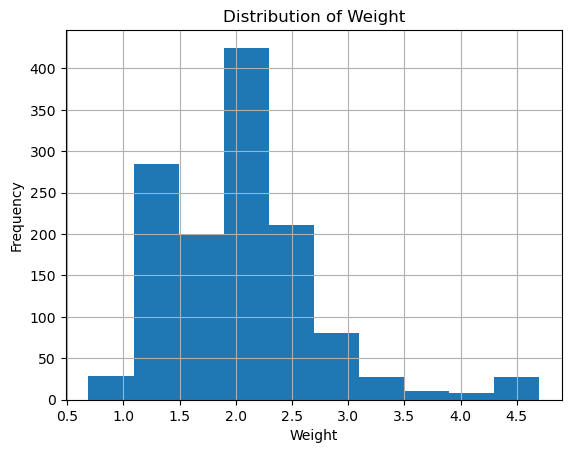

In [101]:
prices['Weight'].hist()
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

<Axes: >

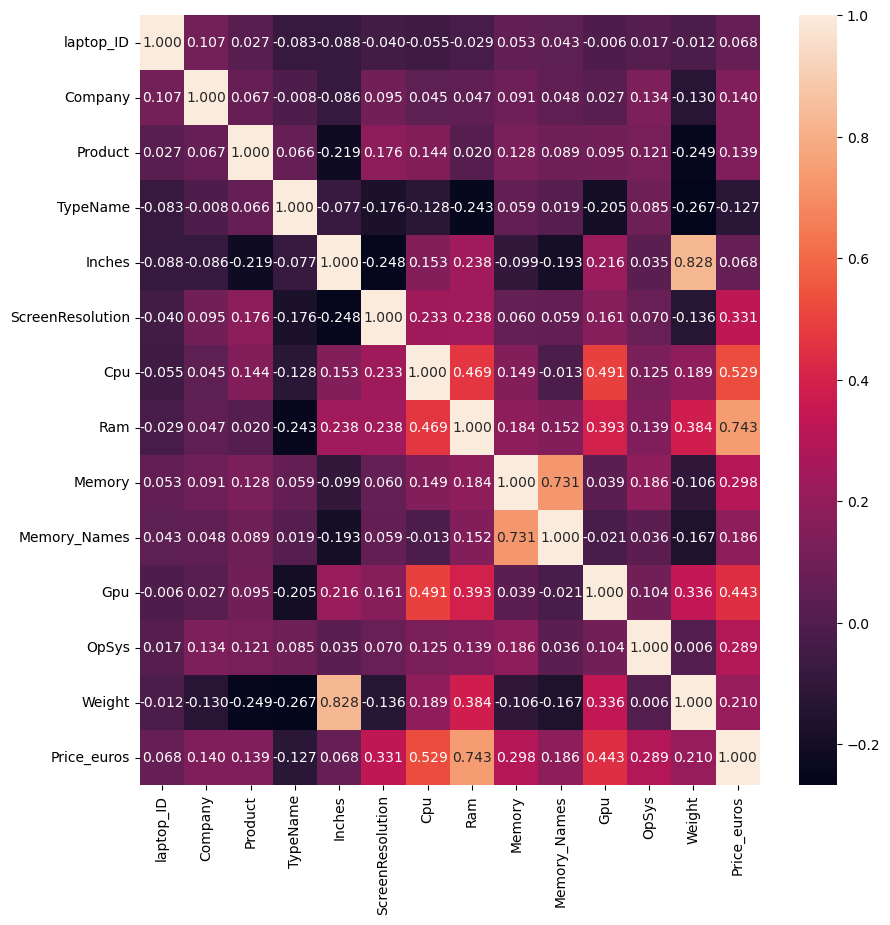

In [102]:

fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f')